# 01211373 : Machine Learning and Programming for Industry

## Lecture 2 Supplement 3 : Decision tree, ensemble learning, and random forests

In this lecture we move on to another algorithm in the category of supervised learning, called decison tree. As the name suggests, we can think of this model as breaking down our data by making a decision based on asking a series of questions. Then we discuss ensemble methods to combine different classifiers into a meta-classfier that has better generalization performance than each individual classifier alone. random forest can be considered as an ensemble of decision trees.


### 5.1 Decision tree

AI overview of decision tree

"A decision tree is a flowchart-like model that helps in making decisions by mapping out a sequence of choices, their potential outcomes, costs, benefits, and probabilities. It consists of nodes and branches, with decision nodes representing choices, chance nodes indicating uncertain outcomes, and leaf nodes signifying the final result. Decision trees are used in various fields, from machine learning to business and medicine, to classify data, predict outcomes, and guide complex decision-making processes in an easy-to-understand, hierarchical structure."

Figure 5.1 shows a simple example of a dicision tree, in which a student chooses his activity in a particular day.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/dt_example.png" width=800 />

Figure 5.1 a decision tree example

**Note :** Some activity in this decision tree may look different from other regions in the world. It takes into account the extreme heat during sunny day in Thailand. People often choose to stay inside.  

Though Figure 5.1 illustrates a decision tree with categorical variables, it can be applied when features are real numbers, or even a regression problem. Using the decision algorithm, we start at the tree root and split the data on the feature that results in
the largest **information gain (IG).** We repeat this splitting procedure at each child node iteratively until the leaves are pure; i.e., the training examples at each node belong to the same class. Since a very deep tree is prone to overfitting, in practice we may set a limit for maximum depth of tree. This could result in some leave node not 100% pure but have the majority belong to a class.

#### 5.1.1 Information Gain 

Information gain (IG) is defined as follows:
$$
IG(D_p,f) = I(D_p) - \sum_{j=1}^{m}\frac{N_j}{N_p}I(D_j) \tag{5.1}
$$
where $f$ is the feature to perform the split; $D_p$ and $D_j$ are the dataset of the parent and $j$ th child node; $I$ is **impurity** measure; $N_p$ is the total number of training examples at the parent node; and $N_j$ is the number of examples in the $j$ th child node. The information gain is the difference
between the impurity of the parent node and the sum of the child node impurities—the lower the
impurities of the child nodes, the larger the information gain.

Most libraries including scikit-learn implement binary decision trees, with IG defined as
$$
IG(D_p,f) = I(D_p) - \frac{N_{left}}{N_p}I(D_{left})- \frac{N_{right}}{N_p}I(D_{right})\tag{5.2}
$$

The three commonly-used impurity measures for binary decison tree are

##### Entropy

$$
I_H(t) = - \sum_{i=1}^{c}p(i|t)log_2(i|t) \tag{5.3}
$$

$p(i|t)$ is the proportion of examples that belong to class $i$ for a particular node $t$. Note that the entropy is $0$ if all examples at a node belong to the same class, and is maximal if we have a uniform class distribution. 

Let's visualize the entropy values for different class distributions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

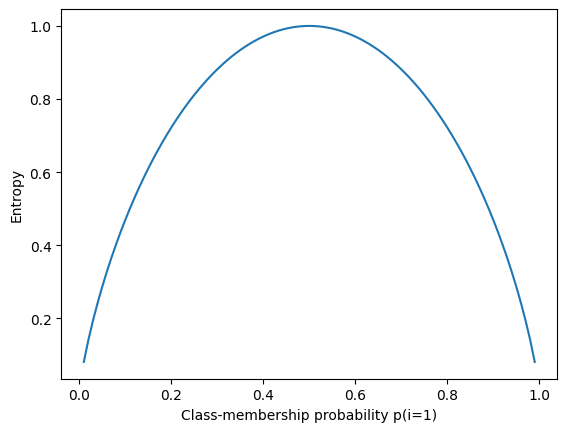

In [2]:
def entropy(p):
    return - p * np.log2(p) - (1 - p) * np.log2((1 - p))

x = np.arange(0.0, 1.0, 0.01)
ent = [entropy(p) if p != 0 else None 
       for p in x]

plt.ylabel('Entropy')
plt.xlabel('Class-membership probability p(i=1)')
plt.plot(x, ent)
plt.show()

##### Gini impurity

The Gini impurity can be understood as a criterion to minimize the probability of misclassification:

$$
I_G(t) = \sum_{i=1}^c p(i|t)(1 - p(i|t)) = 1 - \sum_{i=1}^c p(i|t)^2 \tag{5.4}
$$

Note that the Gini impurity is maximal when the classes are perfectly mixed. For example, in a binary class setting (c=2)
$$
I_G(t) = 1 - \sum_{i=1}^c 0.5^2 = 0.5
$$
and is $0$ when all examples are correctly classified. 

In practice, the Gini impurity and entropy typically yield very similar results. 

##### Classification error

$$
I_E(t) = 1 - max \; p(i|t) \tag{5.5}
$$

This is not recommended for growing a decision tree, since it is less sensitive to changes in the class probabilities of the nodes. See [1] for an example.

For visual comparision of the three impurity criteria, let's plot the impurity indices for probability range [0,1] for one particular class. Note that we scale the intropy by 1/2 to make the plots comparable. 

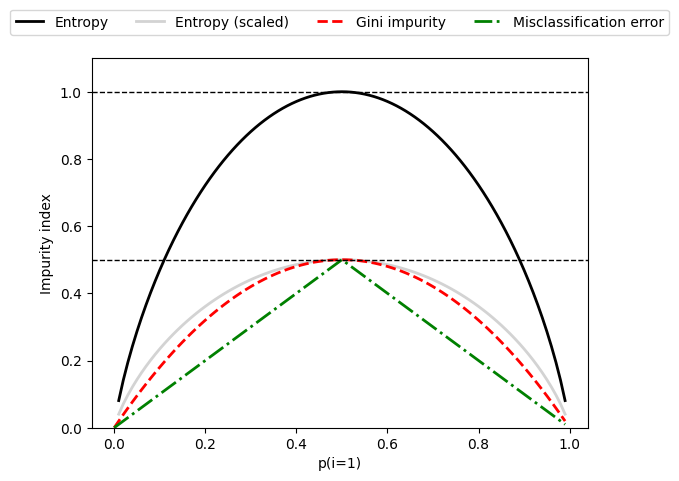

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def gini(p):
    return p * (1 - p) + (1 - p) * (1 - (1 - p))


def entropy(p):
    return - p * np.log2(p) - (1 - p) * np.log2((1 - p))


def error(p):
    return 1 - np.max([p, 1 - p])

x = np.arange(0.0, 1.0, 0.01)

ent = [entropy(p) if p != 0 else None for p in x]
sc_ent = [e * 0.5 if e else None for e in ent]
err = [error(i) for i in x]

fig = plt.figure()
ax = plt.subplot(111)
for i, lab, ls, c, in zip([ent, sc_ent, gini(x), err], 
                          ['Entropy', 'Entropy (scaled)', 
                           'Gini impurity', 'Misclassification error'],
                          ['-', '-', '--', '-.'],
                          ['black', 'lightgray', 'red', 'green', 'cyan']):
    line = ax.plot(x, i, label=lab, linestyle=ls, lw=2, color=c)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15),
          ncol=5, fancybox=True, shadow=False)

ax.axhline(y=0.5, linewidth=1, color='k', linestyle='--')
ax.axhline(y=1.0, linewidth=1, color='k', linestyle='--')
plt.ylim([0, 1.1])
plt.xlabel('p(i=1)')
plt.ylabel('Impurity index')
#plt.savefig('figures/03_19.png', dpi=300, bbox_inches='tight')
plt.show()

#### 5.1.2 Building a decision tree with scikit-learn

Now we build a decision tree with scikit-learn for the iris dataset. 

Decision trees can create complex decision boundaries by dividing the feature spaces into rectangles. The deeper the decision tgree, the more complex the decision boundary, which can easily result in overfitting. So we must limit the maximum depth to, say, 4. You can experiment with the entropy or Gini impurity for the impurity criterion.

In [4]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

Class labels: [0 1 2]
Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


In [5]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# To check recent matplotlib compatibility
import matplotlib
from distutils.version import LooseVersion


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='Test set')        

#### Building a decision tree.

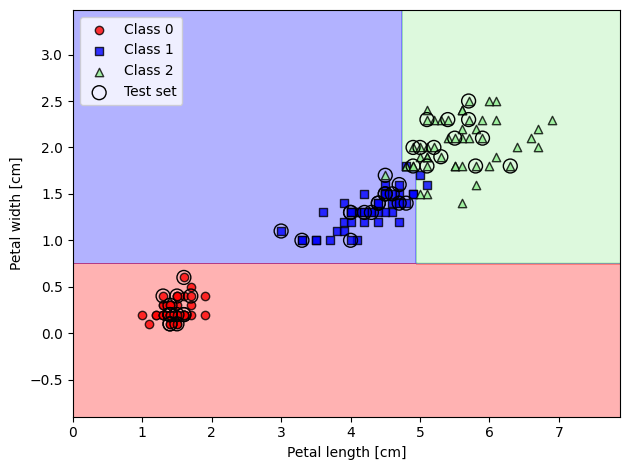

In [6]:
from sklearn.tree import DecisionTreeClassifier

# try changing the hyperparameters such as criterion = 'entropy','gini','log_loss'
# incresing max_depth would result in overfitting 
tree_model = DecisionTreeClassifier(criterion='gini', 
                                    max_depth=4, 
                                    random_state=1)
tree_model.fit(X_train, y_train)

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=tree_model,
                      test_idx=range(105, 150))

plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

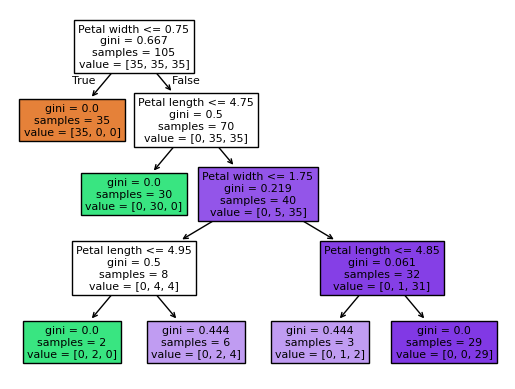

In [ ]:
from sklearn import tree

# feature_names = ['Sepal length', 'Sepal width',
#                  'Petal length', 'Petal width']
feature_names = ['Petal length', 'Petal width'] # use only feature [2,3]
tree.plot_tree(tree_model,
               feature_names=feature_names,
               filled=True)
plt.show()

### 5.2 Ensemble learning 

From wikipedia https://en.wikipedia.org/wiki/Ensemble_learning 

"In statistics and machine learning, ensemble methods use multiple learning algorithms to obtain better predictive performance than could be obtained from any of the constituent learning algorithms alone. Unlike a statistical ensemble in statistical mechanics, which is usually infinite, a machine learning ensemble consists of only a concrete finite set of alternative models, but typically allows for much more flexible structure to exist among those alternatives."

**Note :** Our ensemble discussion here follows [1]. We focus on experimenting with the provided code. Advanced details may be omitted.

#### 5.2.1 Ensemble approach based on majority voting

**Note :** We have abused the term "majority vote" in place of "plurality vote." Read explanation in [1]

Figure 5.2 illustrates the concept of a general ensemble approach using majority voting. To predict a class label via simple majority or plurality voting, we can combine the predicted class labels of each individual classifier, $C_j$, and select the class label, $\hat{y}$ , that received the most votes.
$$
\hat{y} = mode(C_1(x), C_2(x),\ldots,C_m(x)) \tag{5.6}
$$
In statistics, the mode is the most frequent event or result in a set. For example $mode(3,2,3,5,4,3,4) = 3.$

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_02.png" width=800 />

Figure 5.2 A general ensemble approach (from Figure 7.2 of [1])

Read [1] for more details. Here we provide only the code. 

This cell below just verifies p. 207 of [1].


In [8]:
from scipy.special import comb
import math


def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.))
    probs = [comb(n_classifier, k) * error**k * (1-error)**(n_classifier - k)
             for k in range(k_start, n_classifier + 1)]
    return sum(probs)

In [9]:
ensemble_error(n_classifier=11, error=0.25)

np.float64(0.03432750701904297)

After we have implemented the ensemble_error function, we can compute the ensemble error rates 
for a range of different base errors from 0.0 to 1.0 to visualize the relationship between ensemble and 
base errors in a line graph:

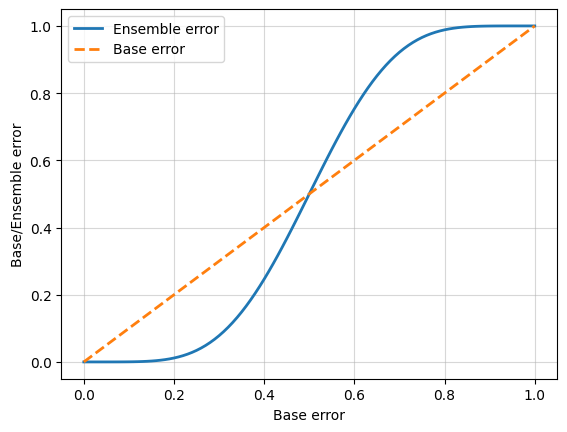

In [10]:
error_range = np.arange(0.0, 1.01, 0.01)
ens_errors = [ensemble_error(n_classifier=11, error=error)
              for error in error_range]
plt.plot(error_range, 
         ens_errors, 
         label='Ensemble error', 
         linewidth=2)

plt.plot(error_range, 
         error_range, 
         linestyle='--',
         label='Base error',
         linewidth=2)

plt.xlabel('Base error')
plt.ylabel('Base/Ensemble error')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

From the result, the error probability of an ensemble is always better than the error of an individual base classifier as long as $\epsilon \lt 0.5$. (A base classifier with $\epsilon \gt 0.5$ performs worse than random guessing so it's useless.)

#### 5.2.2 Implementing a simple majority vote classifier

In this scetion we build a stronger meta-classifier that balances out different classification algorithms associated with individual weights for confidence. Mathematically, the weighted majority vote is defined as
$$
\hat{y} = \underset{i}{arg \;max} \sum_{j=1}^m w_j\chi_A(C_j(x)= i) \tag{5.7}
$$
where $w_j$ is a weight associated with a base classifier $C_j$, $\hat{y}$ is the predicted class label of the ensemble, $A$ is the set of unique class labels, and $\chi_A$ is the characteristic funciton or indicator function, which returns 1 if the predicted class of the jth classifier matches $i$, $C_j(x) = i$. For equal weight, (5.7) is simplified to
$$
\hat{y} = mode(C_1(x),C_2(x),\ldots, C_m(x)) \tag{5.8}
$$
See example on page 210 of [1].

To translate the concept of the weighted majority vote into Python code, we can use NumPy’s convenient
argmax and bincount functions, where bincount counts the number of occurrences of each
class label. The argmax function then returns the index position of the highest count, corresponding
to the majority class label (this assumes that class labels start at 0):




In [11]:
np.argmax(np.bincount([0, 0, 1], weights=[0.2, 0.2, 0.6]))

np.int64(1)

In [12]:
np.argmax(np.bincount([0, 0, 0, 1, 1], weights=[0.2, 0.2,0.2,0.2,0.2 ]))

np.int64(0)

Certain certain classifiers in
scikit-learn can also return the probability of a predicted class label via the predict_proba method. Using the predicted class probabilities instead of the class labels for majority voting can be useful
if the classifiers in our ensemble are well calibrated. The modified version of the majority vote for
predicting class labels from probabilities can be written as follows
$$
\hat{y} = \underset{i}{arg \;max} \sum_{j=1}^m w_jp_{ij} \tag{5.9}
$$
where $p_{ij}$ is the predicted probability of the jth classifier for class label $j$.

To implement the weighted majority vote based on class probabilities, we can again make use of
NumPy, using np.average and np.argmax


In [13]:
ex = np.array([[0.9, 0.1],
               [0.8, 0.2],
               [0.4, 0.6]])

p = np.average(ex, 
               axis=0, 
               weights=[0.2, 0.2, 0.6])
p

array([0.58, 0.42])

In [14]:
np.argmax(p)

np.int64(0)

Let's now implement MajorityVoteClassifier in Python.

In [15]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.pipeline import _name_estimators
import numpy as np
import operator



# Scikit-learn 0.16 and newer requires reversing the parent classes
# See https://github.com/rasbt/machine-learning-book/discussions/205 for more details
import sklearn
base_classes = (ClassifierMixin, BaseEstimator) if sklearn.__version__ >= "0.16" else (BaseEstimator, ClassifierMixin)

# class MajorityVoteClassifier(BaseEstimator, 
#                             ClassifierMixin):

class MajorityVoteClassifier(*base_classes):

    """ A majority vote ensemble classifier

    Parameters
    ----------
    classifiers : array-like, shape = [n_classifiers]
      Different classifiers for the ensemble

    vote : str, {'classlabel', 'probability'} (default='classlabel')
      If 'classlabel' the prediction is based on the argmax of
        class labels. Else if 'probability', the argmax of
        the sum of probabilities is used to predict the class label
        (recommended for calibrated classifiers).

    weights : array-like, shape = [n_classifiers], optional (default=None)
      If a list of `int` or `float` values are provided, the classifiers
      are weighted by importance; Uses uniform weights if `weights=None`.

    """
    def __init__(self, classifiers, vote='classlabel', weights=None):

        self.classifiers = classifiers
        self.named_classifiers = {key: value for key, value
                                  in _name_estimators(classifiers)}
        self.vote = vote
        self.weights = weights

    def fit(self, X, y):
        """ Fit classifiers.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]
            Matrix of training examples.

        y : array-like, shape = [n_examples]
            Vector of target class labels.

        Returns
        -------
        self : object

        """
        if self.vote not in ('probability', 'classlabel'):
            raise ValueError(f"vote must be 'probability' or 'classlabel'"
                             f"; got (vote={self.vote})")

        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(f'Number of classifiers and weights must be equal'
                             f'; got {len(self.weights)} weights,'
                             f' {len(self.classifiers)} classifiers')

        # Use LabelEncoder to ensure class labels start with 0, which
        # is important for np.argmax call in self.predict
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self

    def predict(self, X):
        """ Predict class labels for X.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]
            Matrix of training examples.

        Returns
        ----------
        maj_vote : array-like, shape = [n_examples]
            Predicted class labels.
            
        """
        if self.vote == 'probability':
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:  # 'classlabel' vote

            #  Collect results from clf.predict calls
            predictions = np.asarray([clf.predict(X)
                                      for clf in self.classifiers_]).T

            maj_vote = np.apply_along_axis(
                                      lambda x:
                                      np.argmax(np.bincount(x,
                                                weights=self.weights)),
                                      axis=1,
                                      arr=predictions)
        maj_vote = self.lablenc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):
        """ Predict class probabilities for X.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape = [n_examples, n_features]
            Training vectors, where n_examples is the number of examples and
            n_features is the number of features.

        Returns
        ----------
        avg_proba : array-like, shape = [n_examples, n_classes]
            Weighted average probability for each class per example.

        """
        probas = np.asarray([clf.predict_proba(X)
                             for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0, weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        """ Get classifier parameter names for GridSearch"""
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in self.named_classifiers.items():
                for key, value in step.get_params(deep=True).items():
                    out[f'{name}__{key}'] = value
            return out

* VotingClassifier in scikit-learn : 
Although the MajorityVoteClassifier implementation is very useful for demonstration
purposes, a more sophisticated version of this majority vote classifier is available in
scikit-learn based on the implementation in the first edition of [1]. The ensemble
classifier is available as *sklearn.ensemble.VotingClassifier* in scikit-learn version
0.17 and newer. 

##### Using the majority voting principle to make predictions

Use the iris dataset. Split the examples into 50 percent training and 50 percent tes data.

In [16]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test =\
       train_test_split(X, y, 
                        test_size=0.5, 
                        random_state=1,
                        stratify=y)

Train 3 different classifiers:
* logistic regression
* decision tree
* k-nearest neighbors

In [17]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


clf1 = LogisticRegression(penalty='l2', 
                          C=0.001,
                          solver='lbfgs',
                          random_state=1)

clf2 = DecisionTreeClassifier(max_depth=1,
                              criterion='entropy',
                              random_state=0)

clf3 = KNeighborsClassifier(n_neighbors=1,
                            p=2,
                            metric='minkowski')

pipe1 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf1]])
pipe3 = Pipeline([['sc', StandardScaler()],
                  ['clf', clf3]])

clf_labels = ['Logistic regression', 'Decision tree', 'KNN']

print('10-fold cross validation:\n')
for clf, label in zip([pipe1, clf2, pipe3], clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} '
          f'(+/- {scores.std():.2f}) [{label}]')


10-fold cross validation:

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]


**Note**

* ROC AUC, or Receiver Operating Characteristic Area Under the Curve, is a machine learning metric that measures a binary classification model's ability to distinguish between positive and negative classes across all possible thresholds. It is a probability score, ranging from 0 to 1, where 1 indicates a perfect model and 0.5 indicates a model performing no better than random guessing. A higher ROC AUC score means the model is better at separating the classes.  

Now, use our MajorityVoteClassifier to combine the individual classifiers.


In [18]:
# Majority Rule (hard) Voting

mv_clf = MajorityVoteClassifier(classifiers=[pipe1, clf2, pipe3])

clf_labels += ['Majority voting']
all_clf = [pipe1, clf2, pipe3, mv_clf]

for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(estimator=clf,
                             X=X_train,
                             y=y_train,
                             cv=10,
                             scoring='roc_auc')
    print(f'ROC AUC: {scores.mean():.2f} '
          f'(+/- {scores.std():.2f}) [{label}]')

ROC AUC: 0.92 (+/- 0.15) [Logistic regression]
ROC AUC: 0.87 (+/- 0.18) [Decision tree]
ROC AUC: 0.85 (+/- 0.13) [KNN]
ROC AUC: 0.98 (+/- 0.05) [Majority voting]


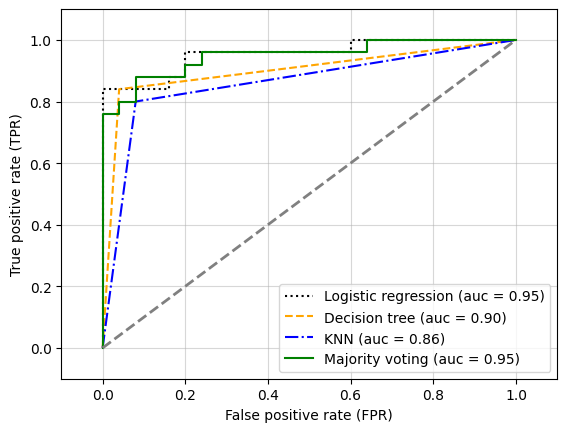

In [19]:
##### Evaluating and tuning the ensemble classifier

from sklearn.metrics import roc_curve
from sklearn.metrics import auc


colors = ['black', 'orange', 'blue', 'green']
linestyles = [':', '--', '-.', '-']
for clf, label, clr, ls \
        in zip(all_clf,
               clf_labels, colors, linestyles):

    # assuming the label of the positive class is 1
    y_pred = clf.fit(X_train,
                     y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test,
                                     y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr,
             color=clr,
             linestyle=ls,
             label=f'{label} (auc = {roc_auc:.2f})')

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1],
         linestyle='--',
         color='gray',
         linewidth=2)

plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel('False positive rate (FPR)')
plt.ylabel('True positive rate (TPR)')


#plt.savefig('figures/07_04', dpi=300)
plt.show()

In [20]:
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)

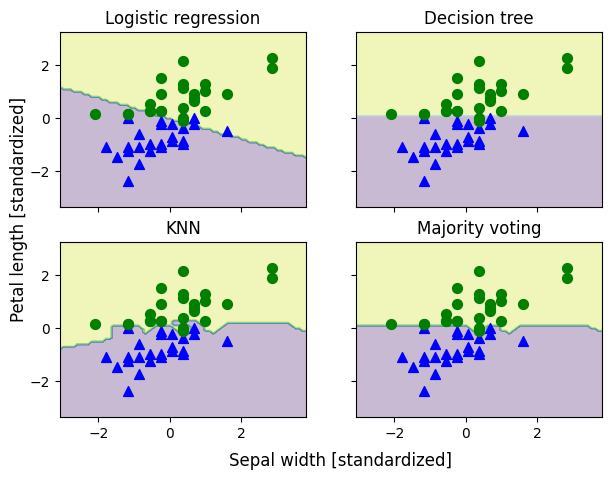

In [21]:
from itertools import product


all_clf = [pipe1, clf2, pipe3, mv_clf]

x_min = X_train_std[:, 0].min() - 1
x_max = X_train_std[:, 0].max() + 1
y_min = X_train_std[:, 1].min() - 1
y_max = X_train_std[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=2, ncols=2, 
                        sharex='col', 
                        sharey='row', 
                        figsize=(7, 5))

for idx, clf, tt in zip(product([0, 1], [0, 1]),
                        all_clf, clf_labels):
    clf.fit(X_train_std, y_train)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.3)
    
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==0, 0], 
                                  X_train_std[y_train==0, 1], 
                                  c='blue', 
                                  marker='^',
                                  s=50)
    
    axarr[idx[0], idx[1]].scatter(X_train_std[y_train==1, 0], 
                                  X_train_std[y_train==1, 1], 
                                  c='green', 
                                  marker='o',
                                  s=50)
    
    axarr[idx[0], idx[1]].set_title(tt)

plt.text(-3.5, -5., 
         s='Sepal width [standardized]', 
         ha='center', va='center', fontsize=12)
plt.text(-12.5, 4.5, 
         s='Petal length [standardized]', 
         ha='center', va='center', 
         fontsize=12, rotation=90)

#plt.savefig('figures/07_05', dpi=300)
plt.show()

In [22]:
mv_clf.get_params()

{'pipeline-1': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', LogisticRegression(C=0.001, random_state=1)]]),
 'decisiontreeclassifier': DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 'pipeline-2': Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]]),
 'pipeline-1__memory': None,
 'pipeline-1__steps': [('sc', StandardScaler()),
  ['clf', LogisticRegression(C=0.001, random_state=1)]],
 'pipeline-1__transform_input': None,
 'pipeline-1__verbose': False,
 'pipeline-1__sc': StandardScaler(),
 'pipeline-1__clf': LogisticRegression(C=0.001, random_state=1),
 'pipeline-1__sc__copy': True,
 'pipeline-1__sc__with_mean': True,
 'pipeline-1__sc__with_std': True,
 'pipeline-1__clf__C': 0.001,
 'pipeline-1__clf__class_weight': None,
 'pipeline-1__clf__dual': False,
 'pipeline-1__clf__fit_intercept': True,
 'pipeline-1__clf__intercept_scaling': 1,
 'pipeline-1__clf__l1_ratio': None,
 'pipeline-1__clf

In [23]:
from sklearn.model_selection import GridSearchCV


params = {'decisiontreeclassifier__max_depth': [1, 2],
          'pipeline-1__clf__C': [0.001, 0.1, 100.0]}

grid = GridSearchCV(estimator=mv_clf,
                    param_grid=params,
                    cv=10,
                    scoring='roc_auc')
grid.fit(X_train, y_train)

for r, _ in enumerate(grid.cv_results_['mean_test_score']):
    mean_score = grid.cv_results_['mean_test_score'][r]
    std_dev = grid.cv_results_['std_test_score'][r]
    params = grid.cv_results_['params'][r]
    print(f'{mean_score:.3f} +/- {std_dev:.2f} {params}')

0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.10 {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 100.0}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.001}
0.983 +/- 0.05 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 0.1}
0.967 +/- 0.10 {'decisiontreeclassifier__max_depth': 2, 'pipeline-1__clf__C': 100.0}


In [24]:
print(f'Best parameters: {grid.best_params_}')
print(f'ROC AUC: {grid.best_score_:.2f}')

Best parameters: {'decisiontreeclassifier__max_depth': 1, 'pipeline-1__clf__C': 0.001}
ROC AUC: 0.98


**Note**  
By default, the default setting for `refit` in `GridSearchCV` is `True` (i.e., `GridSeachCV(..., refit=True)`), which means that we can use the fitted `GridSearchCV` estimator to make predictions via the `predict` method, for example:

    grid = GridSearchCV(estimator=mv_clf, 
                        param_grid=params, 
                        cv=10, 
                        scoring='roc_auc')
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

In addition, the "best" estimator can directly be accessed via the `best_estimator_` attribute.

In [25]:
grid.best_estimator_.classifiers

[Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', LogisticRegression(C=0.001, random_state=1)]]),
 DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=0),
 Pipeline(steps=[('sc', StandardScaler()),
                 ['clf', KNeighborsClassifier(n_neighbors=1)]])]

In [26]:
mv_clf = grid.best_estimator_

In [27]:
mv_clf.set_params(**grid.best_estimator_.get_params())

,pipeline-1,Pipeline(step...om_state=1))])
,decisiontreeclassifier,DecisionTreeC...andom_state=0)
,pipeline-2,Pipeline(step...eighbors=1))])
,pipeline-1__memory,None
,pipeline-1__steps,"[('sc', ...), ('clf', ...)]"
,pipeline-1__transform_input,None
,pipeline-1__verbose,False
,pipeline-1__sc,StandardScaler()
,pipeline-1__clf,LogisticRegre...andom_state=1)
,pipeline-1__sc__copy,True
,pipeline-1__sc__with_mean,True


In [28]:
mv_clf

,pipeline-1,Pipeline(step...om_state=1))])
,decisiontreeclassifier,DecisionTreeC...andom_state=0)
,pipeline-2,Pipeline(step...eighbors=1))])
,pipeline-1__memory,None
,pipeline-1__steps,"[('sc', ...), ('clf', ...)]"
,pipeline-1__transform_input,None
,pipeline-1__verbose,False
,pipeline-1__sc,StandardScaler()
,pipeline-1__clf,LogisticRegre...andom_state=1)
,pipeline-1__sc__copy,True
,pipeline-1__sc__with_mean,True


#### 5.2.2 Bagging

Bagging stands for bootstrap aggregating, an ensemble learning method closely related to the majority vote method in previous section. Instead of using the same training dataset to fit the
individual classifiers in the ensemble, however, we draw bootstrap samples (random samples with replacement) from the initial training dataset. This concept is summarized in Figure 5.3 below

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_06.png" width=800 />

Figure 5.3 Bagging concept (from Figure 7.6 of [1])

let’s consider the example shown in Figure 5.4. Here, we have seven different training instances (denoted
as indices 1-7) that are sampled randomly with replacement in each round of bagging. Each
bootstrap sample is then used to fit a classifier, Cj, which is most typically an unpruned decision tree.

<img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/refs/heads/main/ch07/figures/07_07.png" width=1000 />

Figure 5.4 An example of bagging (from Figure 7.7 of [1])

##### Applying bagging to classify examples in the Wine dataset

let’s create a more complex classification problem using the Wine dataset. Here, we will
only consider the Wine classes 2 and 3, and we will select two features – Alcohol and OD280/OD315
of diluted wines

In [29]:
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
                   'Proline']

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)

# drop 1 class
df_wine = df_wine[df_wine['Class label'] != 1]

y = df_wine['Class label'].values
X = df_wine[['Alcohol', 'OD280/OD315 of diluted wines']].values

Encode the class labels into binary format and split the dataset into 80 percent training
and 20 percent test datasets.

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test =\
            train_test_split(X, y, 
                             test_size=0.2, 
                             random_state=1,
                             stratify=y)

In scikit-learn, import BaggingClassifier from ensemble submodule. We will use an unpruned decision tree as the base classifier and create an
ensemble of 500 decision trees fit on different bootstrap samples of the training dataset.

**Note :** From the code provided with [1], change *base_estimator* to *estimator*.  

In [31]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', 
                              max_depth=None,
                              random_state=1)

bag = BaggingClassifier(estimator=tree,
                        n_estimators=500, 
                        max_samples=1.0, 
                        max_features=1.0, 
                        bootstrap=True, 
                        bootstrap_features=False, 
                        n_jobs=1, 
                        random_state=1)

Calculate the accuracy score to compare the performance of bagging classifer with a unpruned decison tree.

In [32]:
from sklearn.metrics import accuracy_score


tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f'Decision tree train/test accuracies '
      f'{tree_train:.3f}/{tree_test:.3f}')

bag = bag.fit(X_train, y_train)
y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)

bag_train = accuracy_score(y_train, y_train_pred) 
bag_test = accuracy_score(y_test, y_test_pred) 
print(f'Bagging train/test accuracies '
      f'{bag_train:.3f}/{bag_test:.3f}')

Decision tree train/test accuracies 1.000/0.833
Bagging train/test accuracies 1.000/0.917


Compare the decision regions.

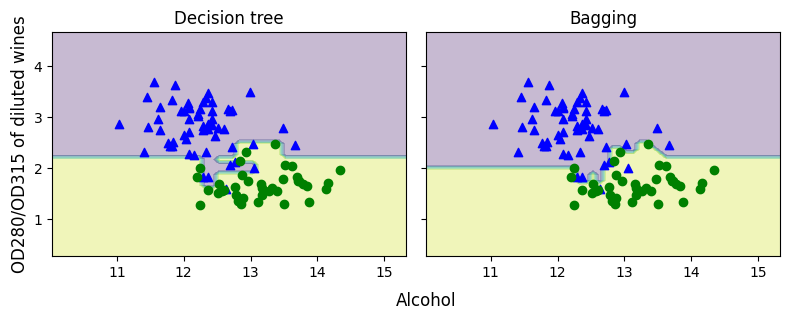

In [33]:
import numpy as np
import matplotlib.pyplot as plt


x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=1, ncols=2, 
                        sharex='col', 
                        sharey='row', 
                        figsize=(8, 3))


for idx, clf, tt in zip([0, 1],
                        [tree, bag],
                        ['Decision tree', 'Bagging']):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(X_train[y_train == 0, 0],
                       X_train[y_train == 0, 1],
                       c='blue', marker='^')

    axarr[idx].scatter(X_train[y_train == 1, 0],
                       X_train[y_train == 1, 1],
                       c='green', marker='o')

    axarr[idx].set_title(tt)

axarr[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)

plt.tight_layout()
plt.text(0, -0.2,
         s='Alcohol',
         ha='center',
         va='center',
         fontsize=12,
         transform=axarr[1].transAxes)

plt.show()

#### 5.2.3 Boosting

We decide to omit boosting ensemble methods (adaptive and gradient boosting) for this semester. See page 229 - 245 of [1] if you are interested.  

## 5.3 Random forests

A random forest can be considered as an ensemble of decision trees. The idea behind a random forest is to average multiple (deep) decisiontrees that individually suffer from high variance to build a more robust model that has a better generalization performance and is less susceptible to overfitting. The random forest algorithm can be summarized in four simple steps:

1. Draw a random bootstrap sample of size $n$ (randomly choose $n$ examples from the training
dataset with replacement).
2. Grow a decision tree from the bootstrap sample. At each node:

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; a. Randomly select $d$ features without replacement.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; b. Split the node using the feature that provides the best split according to the objective
function, for instance, maximizing the information gain.

3. Repeat steps 1-2 $k$ times.
4. Aggregate the prediction by each tree to assign the class label by majority vote. 

Use scikit-learn to grow a random forest for iris classification. 

In [34]:
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target

print('Class labels:', np.unique(y))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print('Labels counts in y:', np.bincount(y))
print('Labels counts in y_train:', np.bincount(y_train))
print('Labels counts in y_test:', np.bincount(y_test))

X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

Class labels: [0 1 2]
Labels counts in y: [50 50 50]
Labels counts in y_train: [35 35 35]
Labels counts in y_test: [15 15 15]


In [35]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

# To check recent matplotlib compatibility
import matplotlib
from distutils.version import LooseVersion


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

    # highlight test examples
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='Test set')        

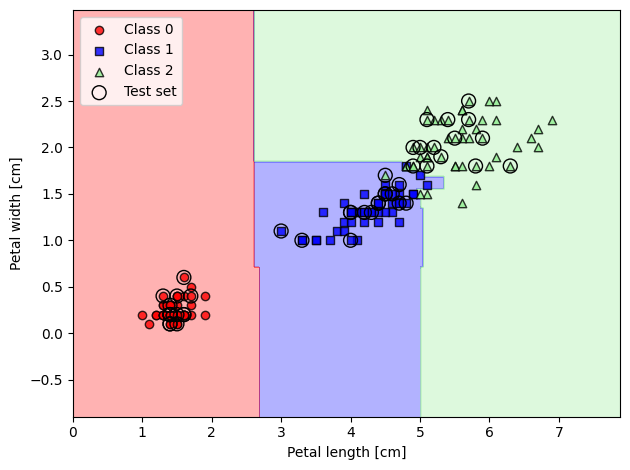

In [36]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=25, 
                                random_state=1,
                                n_jobs=2)
forest.fit(X_train, y_train)

plot_decision_regions(X_combined, y_combined, 
                      classifier=forest, test_idx=range(105, 150))

plt.xlabel('Petal length [cm]')
plt.ylabel('Petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### Related Videos
<ul>
<li />Intro to ML and statistical by Sebastian Raschka, <a href=https://youtube.com/playlist?list=PLTKMiZHVd_2KyGirGEvKlniaWeLOHhUF3&si=kV3ueM1RM3cIGQfb>Playlist</a>
<ul>
<li /><a href="https://sebastianraschka.com/blog/2021/ml-course.html#l06---decision-trees">Decision trees (6.1 - 6.7)</a>
<li /><a href="https://sebastianraschka.com/blog/2021/ml-course.html#l07---ensemble-methods">Ensemble methods (7.1 - 7.7)</a>
</ul>
<li /><a href="https://youtu.be/wr9gUr-eWdA?si=jc60vRtgXougXgdz">CS 229: Lecture 10</a>
<li /><a href="https://youtu.be/ZOiBe-nrmc4?si=7zibGIfK_q3qVfx0">MIT: Machine Learning 6.036, Lecture 12: Decision trees and random forests (Fall 2020)</a>
</ul>



### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  

2. A. Ng. [CS229 Lecture Notes.](https://cs229.stanford.edu/main_notes.pdf) Stanford University. 2023.[Related video](https://youtu.be/4b4MUYve_U8?si=qa3iBTO2R-abQViu) 

3. T. Broderick. [Introduction to Machine Learning course (6.036).](https://tamarabroderick.com/ml.html) Massachusetts Institute of Technology. 2020. [Related video](https://youtu.be/OpvrwhWEUmY?si=bS8VZYsrZMqvnuII)  

4. S. Raschka. [Introduction to Machine Learning course](https://sebastianraschka.com/blog/2021/ml-course.html). L06: [Slides](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/06-trees__slides.pdf) [Notes](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/06-trees__notes.pdf) L07 :[Slides](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/07-ensembles__slides.pdf) [Notes](https://sebastianraschka.com/pdf/lecture-notes/stat451fs20/07-ensembles__notes.pdf) [Code](https://github.com/rasbt/stat451-machine-learning-fs20/blob/master/L07/code/07_code-from-slides.ipynb). University of Wisconsin, Madison. 2021



<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>